In [24]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


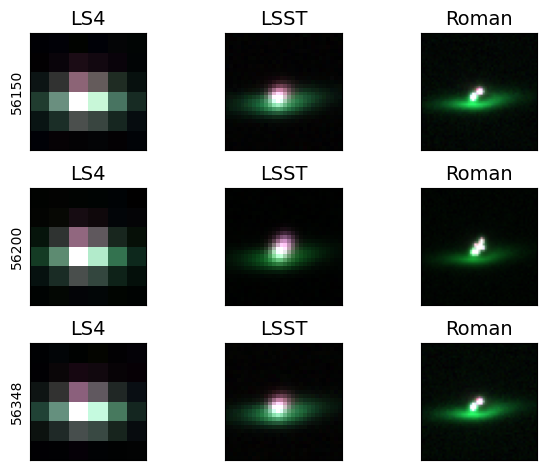

In [30]:
def normalize(data):
    norm = simple_norm(data, 'linear', percent=99)
    return norm(data)

def make_rgb_image(r_file, g_file, i_file):
    r = fits.getdata(r_file)
    g = fits.getdata(g_file)
    i = fits.getdata(i_file)
    return np.dstack((normalize(r), normalize(g), normalize(i)))

# Load RGB images for each telescope
def load_rbg_image(telescope, time, ind):
    dir = 'outputs/SNsims_TD_noise/img_'+ind+'/'
    rgb_im = make_rgb_image(dir+'image_'+telescope+'_r_'+ind+'_newSN_'+time+'.fits', 
                               dir+'image_'+telescope+'_g_'+ind+'_newSN_'+time+'.fits', 
                               dir+'image_'+telescope+'_i_'+ind+'_newSN_'+time+'.fits')
    return rgb_im
    
times = np.linspace(56150,56350,3)
# ind = [146401, 9403, 17462, 43126, 60905, 210697, 134600
# 134600 - quad for 11 days

times = [56150,56200, 56348]

ind = 124869


fig, axes = plt.subplots(len(times), 3)
titles = ['LS4', 'LSST', 'Roman']
for i, time in enumerate(times):
    axs = axes[i]
    
    rgb_lsst = load_rbg_image('LSST', str(time), str(ind))
    rgb_roman = load_rbg_image('Roman', str(time), str(ind))
    rgb_ls4 = load_rbg_image('LS4', str(time), str(ind))
    rgb_images = [ rgb_ls4, rgb_lsst, rgb_roman]
    
    for j, (ax, img, title) in enumerate(zip(axs, rgb_images, titles)):
        if j == 0:
            ax.set_ylabel(time)
        ax.imshow(img, origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=14)
    

plt.tight_layout()
plt.show()
